# CNNs: getting embeddings from pre-trained CNNs

In this lab, we will use a pre-trained CNN (ResNet-18) to obtain embeddings from an image.
Specifically, we will download a [dataset of surface defects of hot-rolled steel strips by Kechen Song and Yunhui Yan](https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database).
The data contains image of steel samples exhibiting characteristics of the following classes: rolled-in scale (RS), patches (Pa), crazing (Cr), pitted surface (PS), inclusion (In) and scratches (Sc).
The database has 1,800 grayscale images.

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install torch torchvision
    !pip install tqdm
    !pip install plotly
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/11-CNNs"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
%%bash

TARGET=data/neu-surface-defect-database.zip

# Create directory if not exists
mkdir -p data

# Download file if it does not exist
if [[ ! -e $TARGET ]]; then
    curl -L -o $TARGET \
      https://www.kaggle.com/api/v1/datasets/download/kaustubhdikshit/neu-surface-defect-database
fi

# Unzip dataset
unzip -q -o $TARGET -d data

In [3]:
import os
import io
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

In [4]:
import umap
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

## Loading the images

The commands below define a transform for the data, which will be preprocessed prior to be sent to the model.
Given that we are using a pre-trained model, we have to adapt to the standards of this model.
The transformations do the following:

- Convert the grayscale image to a 3-channel image (by repeating channels)
- Resize to 224x224 (the size expected by this ResNet model.)
- Convert to a tensor and normalize with ImageNet statistics.

If we were training a CNN from scratch, this would not be necessary

In [6]:
data_dir = "data/NEU-DET/train/images"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # convert grayscale to 3 channels
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet means
                         std=[0.229, 0.224, 0.225])    # ImageNet stds
])

# Use ImageFolder which assigns labels based on the subfolder names.
dataset = ImageFolder(root=data_dir, transform=transform)
print(f"Found {len(dataset)} images in {len(dataset.classes)} classes: {dataset.classes}")

Found 1440 images in 6 classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


Now, we can create a DataLoader, which allows us to perform the operations in batches and make the most of GPU acceleration

In [7]:
batch_size = 128
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

## Loading the model

To load the model, we will define the device where the operations will be performed, then download the model weights for the pretrained ResNet18. Finally, we use the embedding layer of the ResNet-18 (prior to classification) to generate embeddings for each of the images.

In [8]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [9]:
# Use a pretrained ResNet18.
model = models.resnet18(pretrained=True)
model.eval()

# Remove the final classification layer.
# (ResNet’s children: the last layer is the fully connected layer.)
embedding_model = torch.nn.Sequential(*list(model.children())[:-1])
embedding_model.eval()
embedding_model = embedding_model.to(device)

/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Generating embeddings and unsupervised learning model

With the pre-trained model already loaded, we will obtain representations for each of the images.

In [10]:
all_embeddings = []
with torch.no_grad():
    for batch_imgs, _ in tqdm.tqdm(dataloader):
        batch_imgs = batch_imgs.to(device)
        embeddings = embedding_model(batch_imgs)
        embeddings = embeddings.view(embeddings.size(0), -1)  # shape: (batch, 512)
        all_embeddings.append(embeddings)
        
# Concatenate all batches.
all_embeddings = torch.cat(all_embeddings, dim=0).cpu().numpy()
print("Embeddings shape:", all_embeddings.shape)

100%|████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.60it/s]

Embeddings shape: (1440, 512)


In [11]:
umap_2d = umap.UMAP(n_components=2, metric="cosine")
embeddings_2d = umap_2d.fit_transform(all_embeddings)
print("UMAP embeddings shape:", embeddings_2d.shape)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP embeddings shape: (1440, 2)


## Creating an interactive visualization

Finally, once we have the embeddings, we can visualize the data. Instead of making a simple data visualization, though, we will use an interactive visualization to look at the images.

In [12]:
img_paths = [path for (path, _) in dataset.imgs]
labels = [dataset.classes[label] for (_, label) in dataset.imgs]

df = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "label": labels,
    "paths": img_paths
})

In [13]:
# Assume df has the following columns: "x", "y", "label", "paths"
# First, create a numeric mapping for the categorical labels.
unique_labels = df["label"].unique()
label_to_num = {label: i for i, label in enumerate(unique_labels)}
df["label_num"] = df["label"].map(label_to_num)

# Create the Plotly FigureWidget.
fig = go.FigureWidget(
    data=go.Scatter(
        x=df["x"],
        y=df["y"],
        mode="markers",
        marker=dict(
            size=10,
            # Use the numeric mapping for the color.
            color=df["label_num"],
            colorscale="Viridis",
            showscale=True
        ),
        # Pass the image file paths as customdata.
        customdata=np.array(df["paths"]),
        # Show the label on hover (the hovertemplate will only show the label).
        hovertemplate="<b>Label:</b> %{text}<extra></extra>",
        text=df["label"]
    )
)

# Create an Image widget to display the hovered image.
initial_path = df["paths"].iloc[0]
with open(initial_path, "rb") as f:
    initial_img = f.read()

hover_image = widgets.Image(
    value=initial_img,
    format="png",
    width=200,
    height=200
)

# Display the image widget.
display(hover_image)

# Define a callback function to update the image widget on hover.
def update_hover(trace, points, state):
    if points.point_inds:
        # Get the index of the first hovered point.
        i = points.point_inds[0]
        # Retrieve the image path from customdata.
        img_path = trace.customdata[i]
        # Open and load the image.
        with open(img_path, "rb") as f:
            hover_image.value = f.read()

# Bind the hover callback to the scatter trace.
fig.data[0].on_hover(update_hover)
fig

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x02\…

/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/plotly/io/_renderers.py:51: UserWarning:

Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.5.7 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.



FigureWidget({
    'data': [{'customdata': array(['data/NEU-DET/train/images/crazing/crazing_1.jpg',
                                   'data/NEU-DET/train/images/crazing/crazing_10.jpg',
                                   'data/NEU-DET/train/images/crazing/crazing_100.jpg', ...,
                                   'data/NEU-DET/train/images/scratches/scratches_97.jpg',
                                   'data/NEU-DET/train/images/scratches/scratches_98.jpg',
                                   'data/NEU-DET/train/images/scratches/scratches_99.jpg'],
                                  shape=(1440,), dtype=object),
              'hovertemplate': '<b>Label:</b> %{text}<extra></extra>',
              'marker': {'color': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'UFBQUFBQUFBQUFBQUFBQUFBQUFBQUF'),
                                   'dtype': 'i1'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.22222222

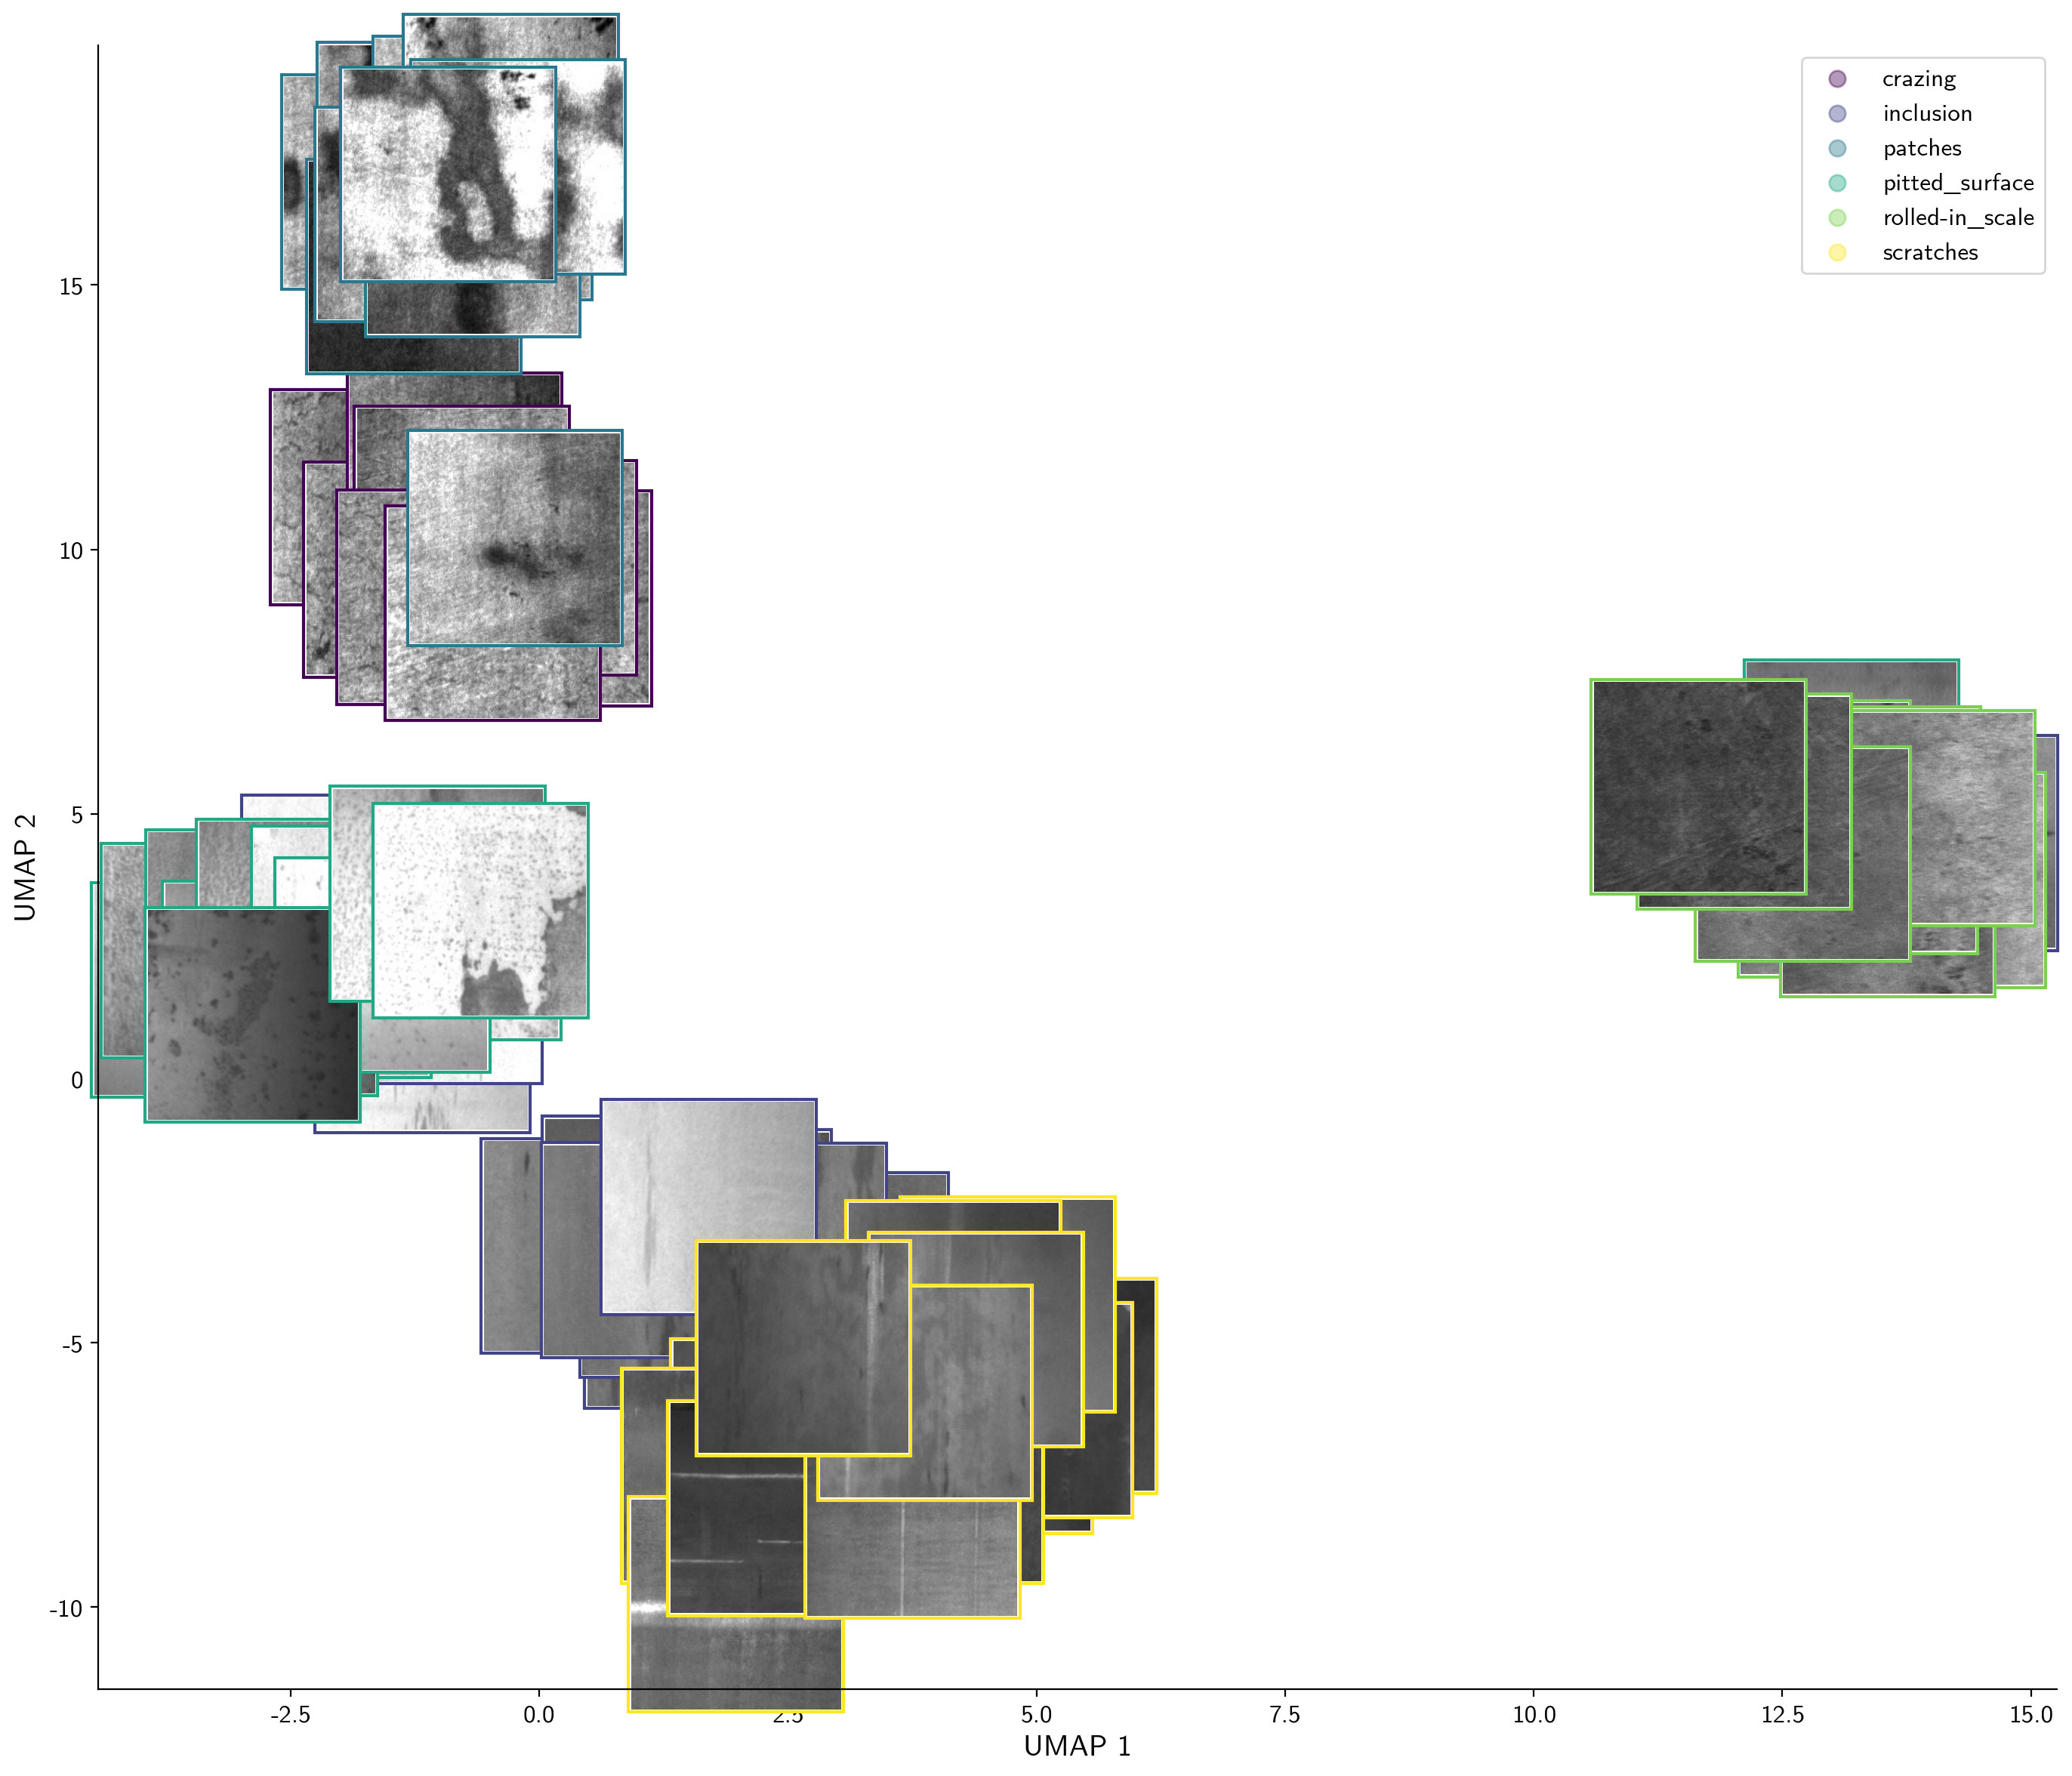

In [15]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.image import imread
import numpy as np

def plot_umap_with_thumbnails(df, zoom=0.15, min_dist=None, figsize=(14, 12)):
    fig, ax = plt.subplots(figsize=figsize)

    unique_labels = df["label"].unique()
    cmap = plt.cm.viridis
    n = max(1, len(unique_labels) - 1)
    label_to_color = {l: cmap(i / n) for i, l in enumerate(unique_labels)}

    # Background scatter (faded; thumbnails sit on top)
    for label in unique_labels:
        sub = df[df["label"] == label]
        ax.scatter(sub["x"], sub["y"], color=label_to_color[label],
                   label=label, s=15, alpha=0.4, zorder=1)

    # Optional spatial subsampling so thumbnails don't overlap
    if min_dist is not None:
        coords = df[["x", "y"]].to_numpy()
        kept = []
        for i in range(len(coords)):
            if all(np.linalg.norm(coords[i] - coords[j]) > min_dist for j in kept):
                kept.append(i)
        plot_df = df.iloc[kept]
    else:
        plot_df = df

    # Embed thumbnails, bordered by class color
    for _, row in plot_df.iterrows():
        img = imread(row["paths"])
        im = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(
            im, (row["x"], row["y"]),
            frameon=True, pad=0.1, zorder=2,
            bboxprops=dict(edgecolor=label_to_color[row["label"]], lw=1.5),
        )
        ax.add_artist(ab)

    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.legend(loc="best", frameon=True, markerscale=2)
    plt.tight_layout()
    return fig, ax

fig, ax = plot_umap_with_thumbnails(df, zoom=0.5, min_dist=0.5)
plt.show()

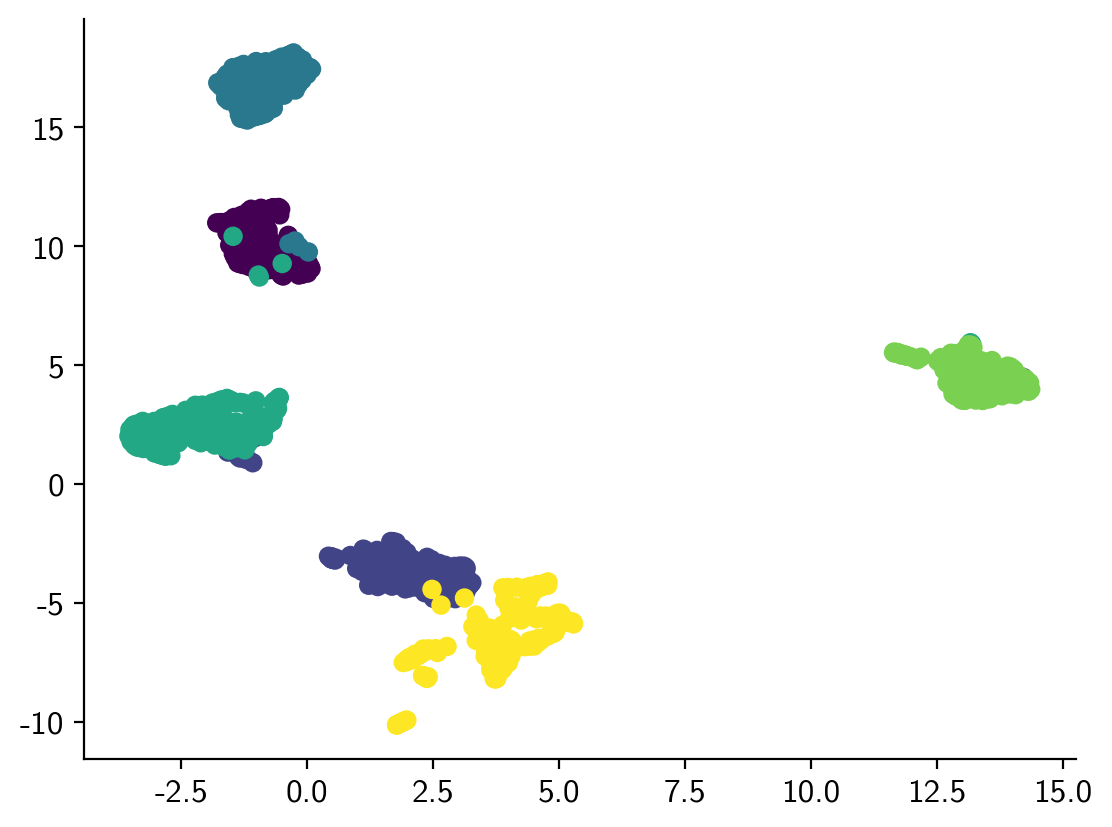

In [21]:
fig, ax = plt.subplots()

ax.scatter(df["x"], df["y"], c=df["label_num"])

plt.show()

## Exercise

Now that you have high-quality embeddings for these images, do you think you could fit simple classifier models to predict the class of the data from the CNN embeddings?